In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

PART 1 DATA UNDERSTANDING

In [4]:
# part 1
df = pd.read_csv("C:/Users/Ahmed Wael/Downloads/Dry_Bean_Dataset.csv")
df.head(5)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [5]:
# part 2
print(f'the number of columns is {len(df.columns)}')
print(f'the number of rows is {len(df)}')


the number of columns is 17
the number of rows is 13611


In [6]:
# part 3 how many unique classes are present?
print(f'The number of unique classes is {len(df['Class'].unique())}')

The number of unique classes is 7


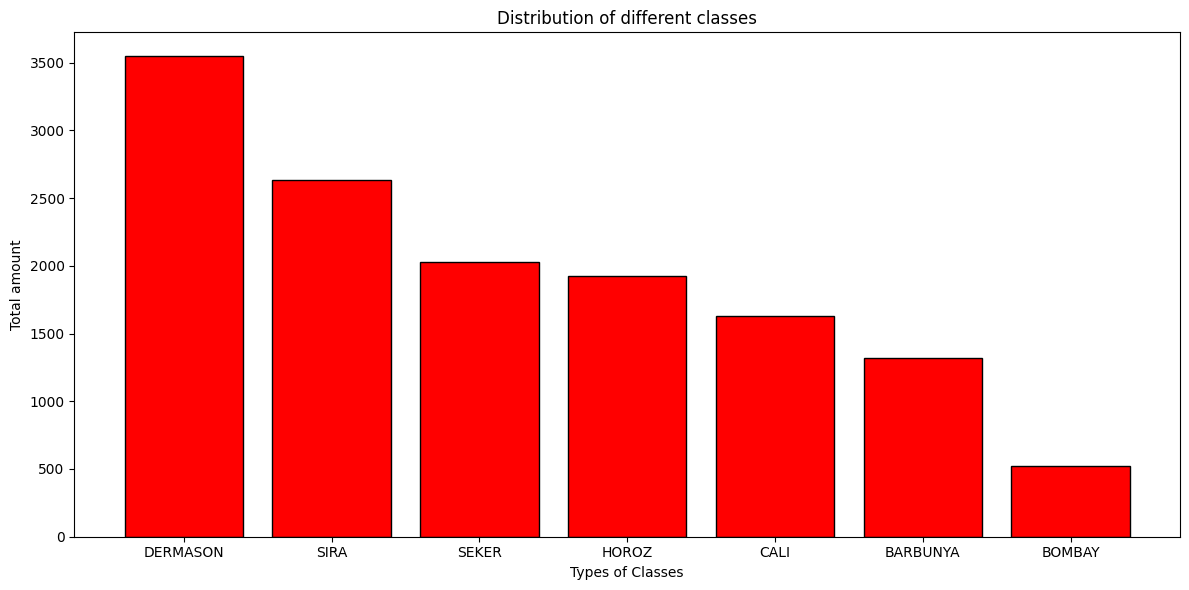

In [7]:
# part 4
class_counts = df['Class'].value_counts()
class_counts
# from seeing the distribution of the classes we can see that the data is imbalanced.

plt.figure(figsize=(12,6))
bar = plt.bar(class_counts.index, class_counts.values, color='red', edgecolor='black')
plt.xlabel('Types of Classes')
plt.ylabel('Total amount')
plt.title('Distribution of different classes')
plt.tight_layout()
plt.show()

PART 2

In [8]:
# part 1
df.isnull().sum()
# there are no missing values

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

In [9]:
# part 2
x = df.drop('Class', axis=1)
y = df['Class']


Q1 = x.quantile(0.25)
Q2 = x.median()
Q3 = x.quantile(0.75)
IQR = Q3 - Q1

print('Q1 Values \n', Q1)
print('*'*80)

print('Q2 Values \n', Q2)
print('*'*80)

print('Q3 Values \n', Q3)
print('*'*80)

print('IQR Values \n', IQR)
print('*'*80)

lower_bound = Q1 - (IQR*1.5)
upper_bound = Q3 + (IQR*1.5)

outlier_index = [] 

for column in x.columns:
    outliers = x[(x[column] < lower_bound[column]) | (x[column] > upper_bound[column])]
    outliers_count = len(outliers)
    print(f'{column}: {outliers_count} outliers')
    outlier_index.extend(outliers.index.tolist())

df_cleaned = df.drop(outlier_index)



Q1 Values 
 Area               36328.000000
Perimeter            703.523500
MajorAxisLength      253.303633
MinorAxisLength      175.848170
AspectRation           1.432307
Eccentricity           0.715928
ConvexArea         36714.500000
EquivDiameter        215.068003
Extent                 0.718634
Solidity               0.985670
roundness              0.832096
Compactness            0.762469
ShapeFactor1           0.005900
ShapeFactor2           0.001154
ShapeFactor3           0.581359
ShapeFactor4           0.993703
Name: 0.25, dtype: float64
********************************************************************************
Q2 Values 
 Area               44652.000000
Perimeter            794.941000
MajorAxisLength      296.883367
MinorAxisLength      192.431733
AspectRation           1.551124
Eccentricity           0.764441
ConvexArea         45178.000000
EquivDiameter        238.438026
Extent                 0.759859
Solidity               0.988283
roundness              0.883157
Comp

In [10]:
# part 3
from sklearn.preprocessing import StandardScaler

# no scaling
x_noscale = x.copy()

for column in x_noscale.columns[:3]:
    print(f'{column}: [{x_noscale[column].min():.2f} to {x_noscale[column].max():.2f}]')
    print(f'There are {len(x_noscale.columns)-3} features left')


#SS
ss = StandardScaler()
x_scaled = ss.fit_transform(x)

x_scaled = pd.DataFrame(x_scaled, columns=x.columns, index=x.index)

for column in x_scaled.columns[:3]:
    print(f"{column}: mean={x_scaled[column].mean():.2f}, std={x_scaled[column].std():.2f}")



Area: [20420.00 to 254616.00]
There are 13 features left
Perimeter: [524.74 to 1985.37]
There are 13 features left
MajorAxisLength: [183.60 to 738.86]
There are 13 features left
Area: mean=0.00, std=1.00
Perimeter: mean=-0.00, std=1.00
MajorAxisLength: mean=0.00, std=1.00


In [11]:
# part 4: Explain why feature scaling significantly affects KNN performance.
# it affects the KNN by scaling the mean and stanard deviation to only 0 to 1 which makes predicitons more reliable and better accuracy 

PART 3

In [12]:
from sklearn.model_selection import train_test_split
# no scaler 70%
X_train_ns_70, X_test_ns_70, y_train_ns_70, y_test_ns_70 = train_test_split(
    x_noscale, y, test_size=0.3, random_state=42, stratify=y)


# scaler 70%
X_train_s_70, X_test_s_70, y_train_s_70, y_test_s_70 = train_test_split(
    x_scaled, y, test_size=0.3, random_state=42, stratify=y)



In [13]:
# no scaler 80
X_train_ns_80, X_test_ns_80, y_train_ns_80, y_test_ns_80 = train_test_split(
    x_noscale, y, test_size=0.2, random_state=42, stratify=y)


# scaler 80
# ========== SCALER - 80% ==========
X_train_s_80, X_test_s_80, y_train_s_80, y_test_s_80 = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
# im going to test on only 70% this is for no scale
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score


knn = KNeighborsClassifier()
knn.fit(X_train_ns_70, y_train_ns_70)
y_pred_70ns = knn.predict(X_test_ns_70)

accuracy_70ns = accuracy_score(y_test_ns_70, y_pred_70ns)
f1_70ns = f1_score(y_test_ns_70, y_pred_70ns, average='weighted')

print(f'70% split without scaling accuarcy was {accuracy_70ns:.2f} and f1_score was {f1_70ns:.2f}')


# with scale
knn.fit(X_train_s_70, y_train_s_70)
y_pred_70s = knn.predict(X_test_s_70)

accuracy_70s = accuracy_score(y_test_s_70, y_pred_70s)
f1_70s = f1_score(y_test_s_70, y_pred_70s, average='weighted')

print(f'70% split with scaling accuarcy was {accuracy_70s:.2f} and f1_score was {f1_70s:.2f}')

print('Now we can see that the accuarcy and f1 scores are very drastic and it proves that standard scaling or feature scaling in general is much more accurate than no scaling')



70% split without scaling accuarcy was 0.72 and f1_score was 0.72
70% split with scaling accuarcy was 0.92 and f1_score was 0.92
Now we can see that the accuarcy and f1 scores are very drastic and it proves that standard scaling or feature scaling in general is much more accurate than no scaling


In [15]:
# 80 no scale
knn.fit(X_train_ns_80, y_train_ns_80)
y_pred_80ns = knn.predict(X_test_ns_80)

accuracy_80ns = accuracy_score(y_test_ns_80, y_pred_80ns)
f1_80ns = f1_score(y_test_ns_80, y_pred_80ns, average='weighted')

print(f'80% split without scaling accuarcy was {accuracy_80ns:.2f} and f1_score was {f1_80ns:.2f}')


# 80 with scale
knn.fit(X_train_s_80, y_train_s_80)
y_pred_80s = knn.predict(X_test_s_80)

accuracy_80s = accuracy_score(y_test_s_80, y_pred_80s)
f1_80s = f1_score(y_test_s_80, y_pred_80s, average='weighted')

print(f'80% split with scaling accuarcy was {accuracy_80s:.2f} and f1_score was {f1_80s:.2f}')

print('Now we can see that the accuarcy and f1 scores are very drastic and it proves that standard scaling or feature scaling in general is much more accurate than no scaling')


80% split without scaling accuarcy was 0.72 and f1_score was 0.72
80% split with scaling accuarcy was 0.92 and f1_score was 0.92
Now we can see that the accuarcy and f1 scores are very drastic and it proves that standard scaling or feature scaling in general is much more accurate than no scaling


PART 4

In [16]:
# part 1 
print(f'70% split without scaling accuarcy was {accuracy_70s:.2f} and f1_score was {f1_70s:.2f}')
print(f'70% split with scaling accuarcy was {accuracy_70s:.2f} and f1_score was {f1_70s:.2f}')
print(f'80% split without scaling accuarcy was {accuracy_80ns:.2f} and f1_score was {f1_80ns:.2f}')
print(f'80% split with scaling accuarcy was {accuracy_80s:.2f} and f1_score was {f1_80s:.2f}')


70% split without scaling accuarcy was 0.92 and f1_score was 0.92
70% split with scaling accuarcy was 0.92 and f1_score was 0.92
80% split without scaling accuarcy was 0.72 and f1_score was 0.72
80% split with scaling accuarcy was 0.92 and f1_score was 0.92


The best k value is 14 because it has an accuarcy of 0.92116%


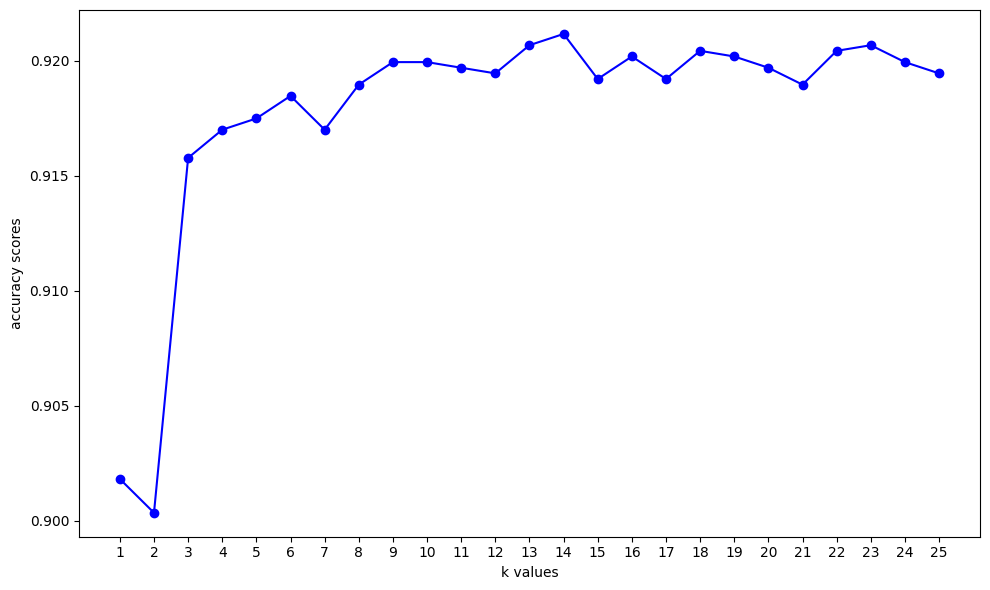

In [17]:
# part 2
k_values = range(1,25+1)
acc_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s_70, y_train_s_70)
    y_pred = knn.predict(X_test_s_70)

    acc_scores.append(accuracy_score(y_test_s_70, y_pred))

best_k = k_values[np.argmax(acc_scores)]
best_acc = max(acc_scores)

print(f'The best k value is {best_k} because it has an accuarcy of {best_acc:.5f}%')

# plotting
plt.figure(figsize=(10,6))
plt.plot(k_values, acc_scores, marker='o', color='blue', label='Comparing the accuracys of k values')
plt.xticks(k_values)
plt.xlabel('k values')
plt.ylabel('accuracy scores')
plt.tight_layout()

In [18]:
# part 3
knn_euclidean = KNeighborsClassifier(n_neighbors=best_k,p=2)
knn_euclidean.fit(X_train_s_70, y_train_s_70)
y_pred_euclidean = knn_euclidean.predict(X_test_s_70)
accuracy_score(y_test_s_70, y_pred_euclidean)


0.9211557296767875

In [19]:
knn_manhattan = KNeighborsClassifier(n_neighbors=best_k,p=1)
knn_manhattan.fit(X_train_s_70, y_train_s_70)
y_pred_manhattan = knn_manhattan.predict(X_test_s_70)
accuracy_score(y_test_s_70, y_pred_manhattan)

0.9194417238001958

In [20]:
# we can see that Euclidean performed better with my results

# mahattan outperforms when there is high dimensional spaces and when there are outliers

# PART 5
|

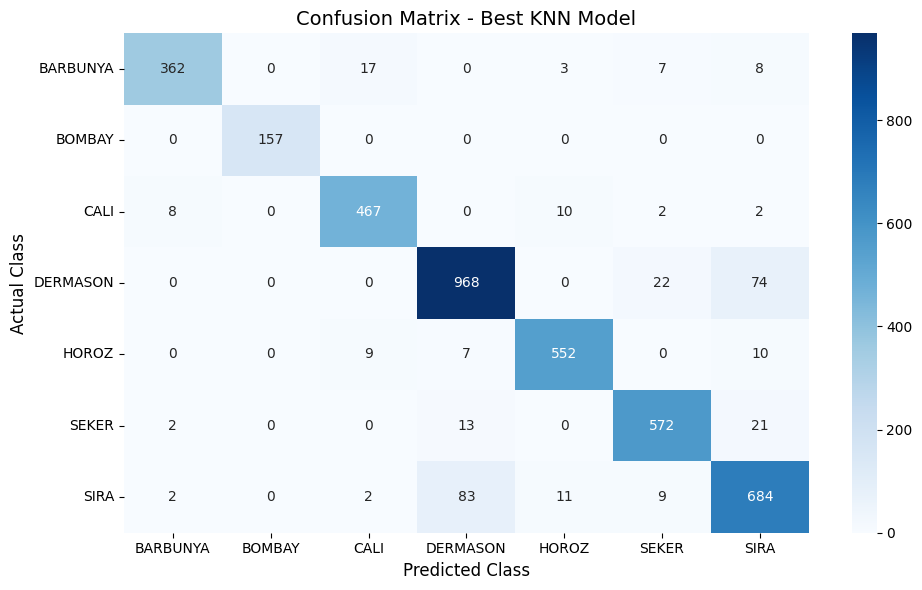

In [21]:
from sklearn.metrics import confusion_matrix, classification_report


knn_best = KNeighborsClassifier(n_neighbors=best_k, p=2)
knn_best.fit(X_train_s_70, y_train_s_70)
y_pred_best = knn_best.predict(X_test_s_70)


cm = confusion_matrix(y_test_s_70, y_pred_best)
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=knn_best.classes_, yticklabels=knn_best.classes_)

plt.title('Confusion Matrix - Best KNN Model', fontsize=14)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('Actual Class', fontsize=12)
plt.tight_layout()



In [ ]:
print(classification_report(y_test_s_70, y_pred_best))
print('Based on the classification report Sira is the most misclassifeid class with f1-score of 0.86')

              precision    recall  f1-score   support

    BARBUNYA       0.97      0.91      0.94       397
      BOMBAY       1.00      1.00      1.00       157
        CALI       0.94      0.96      0.95       489
    DERMASON       0.90      0.91      0.91      1064
       HOROZ       0.96      0.96      0.96       578
       SEKER       0.93      0.94      0.94       608
        SIRA       0.86      0.86      0.86       791

    accuracy                           0.92      4084
   macro avg       0.94      0.93      0.94      4084
weighted avg       0.92      0.92      0.92      4084

